In [3]:
import pandas as pd
train_df = pd.read_csv("/content/drive/MyDrive/projet covid radiographie pulmonaire/train.csv")
val_df = pd.read_csv("/content/drive/MyDrive/projet covid radiographie pulmonaire/validation.csv")
test_df = pd.read_csv("/content/drive/MyDrive/projet covid radiographie pulmonaire/test.csv")

In [ ]:
# Assurez-vous que la colonne 'target' dans train_df_resampled est de type chaîne de caractères pour ImageDataGenerator
train_df_resampled['target'] = train_df_resampled['target'].astype(str)

from tensorflow.keras.preprocessing.image import ImageDataGenerator


BATCH_SIZE = 32
 
IMAGE_SIZE = (224, 224)
COLOR_MODE = 'L' # 'L' pour niveaux de gris, 'RGB' pour couleur

train_datagen_no_aug = ImageDataGenerator(
    rescale=1./255  # Normalisation des pixels à la plage [0, 1]
)

val_train_datagen_no_aug = ImageDataGenerator(
    rescale=1./255  # Normalisation des pixels à la plage [0, 1]
)

k_color_mode = 'grayscale' if COLOR_MODE == 'L' else COLOR_MODE.lower()

train_generator_resampled = train_datagen_no_aug.flow_from_dataframe(
    dataframe=train_df_resampled,
    x_col='filepath',
    y_col='target',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=k_color_mode,
    class_mode='binary',
    shuffle=True,
    seed=42
)

# Créer le générateur de données pour l'ensemble de validation
validation_generator_no_aug = val_train_datagen_no_aug.flow_from_dataframe(
    dataframe=val_gen_df,
    x_col='filepath',
    y_col='target',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=k_color_mode,
    class_mode='binary',
    shuffle=False,
    seed=42
)


train_generator_no_aug = val_train_datagen_no_aug.flow_from_dataframe(
    dataframe=train_gen_df,
    x_col='filepath',
    y_col='target',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=k_color_mode,
    class_mode='binary',
    shuffle=False,
    seed=42
)

print("\nIndices de classe pour le générateur d'entraînement suréchantillonné:")
print(train_generator_resampled.class_indices)

Found 16306 validated image filenames belonging to 2 classes.
Found 2186 validated image filenames belonging to 2 classes.
Found 2813 validated image filenames belonging to 2 classes.

Indices de classe pour le générateur d'entraînement suréchantillonné:
{'0': 0, '1': 1}


In [ ]:
from tensorflow.keras import layers, models, Input
from tensorflow.keras.layers import Dropout

# Définir le modèle CNN
model_no_aug = models.Sequential([
    Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 1)), 
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    Dropout(0.5),
    layers.Dense(1, activation='sigmoid') # Couche de sortie pour classification binaire
])

# Compiler le modèle
model_no_aug.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Afficher le résumé du modèle
model_no_aug.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
from tensorflow.keras.callbacks import EarlyStopping

# Callback d'arrêt anticipé
early_stopping_no_aug = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

epochs = 5

history_no_aug = model_no_aug.fit(
    train_generator_resampled,
    steps_per_epoch=len(train_generator_resampled),
    epochs=epochs,
    validation_data=validation_generator_no_aug,
    validation_steps=len(validation_generator_no_aug),
    callbacks=[early_stopping_no_aug],
    verbose=1
)

Epoch 1/5
510/510 ━━━━━━━━━━━━━━━━━━━━ 1905s 4s/step - accuracy: 0.8353 - loss: 0.3753 - val_accuracy: 0.9190 - val_loss: 0.1863
Epoch 2/5
510/510 ━━━━━━━━━━━━━━━━━━━━ 1891s 4s/step - accuracy: 0.9374 - loss: 0.1687 - val_accuracy: 0.9575 - val_loss: 0.1211
Epoch 3/5
510/510 ━━━━━━━━━━━━━━━━━━━━ 1934s 4s/step - accuracy: 0.9655 - loss: 0.0982 - val_accuracy: 0.9803 - val_loss: 0.0574
Epoch 4/5
510/510 ━━━━━━━━━━━━━━━━━━━━ 1875s 4s/step - accuracy: 0.9741 - loss: 0.0723 - val_accuracy: 0.9812 - val_loss: 0.0525
Epoch 5/5
510/510 ━━━━━━━━━━━━━━━━━━━━ 1853s 4s/step - accuracy: 0.9822 - loss: 0.0502 - val_accuracy: 0.9849 - val_loss: 0.0438


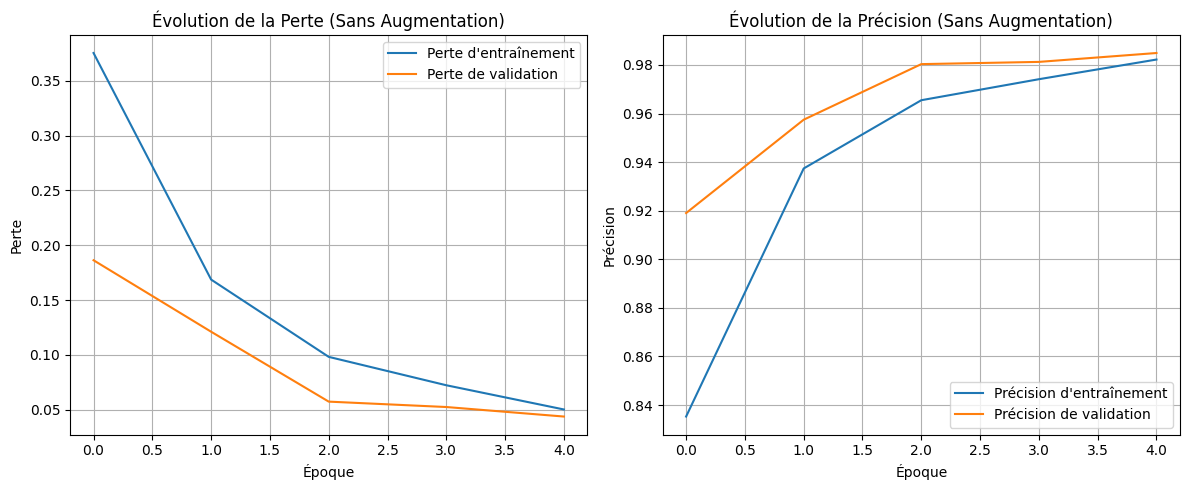

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_no_aug.history['loss'], label='Perte d\'entraînement')
plt.plot(history_no_aug.history['val_loss'], label='Perte de validation')
plt.title('Évolution de la Perte (Sans Augmentation)')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_no_aug.history['accuracy'], label='Précision d\'entraînement')
plt.plot(history_no_aug.history['val_accuracy'], label='Précision de validation')
plt.title('Évolution de la Précision (Sans Augmentation)')
plt.xlabel('Époque')
plt.ylabel('Précision')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

88/88 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step


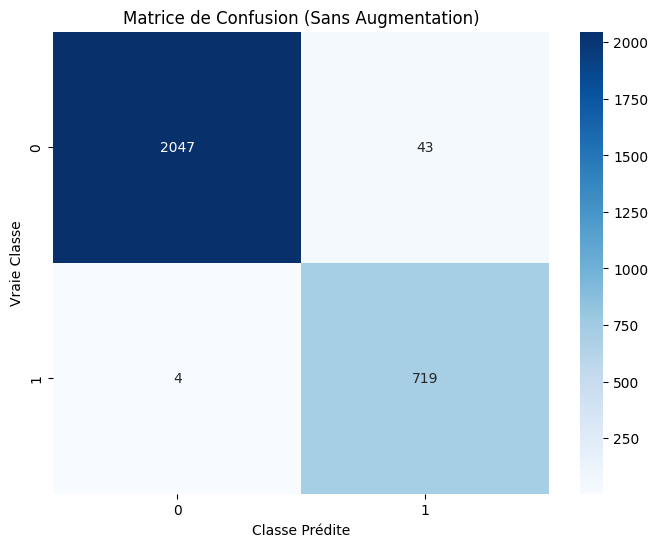


Rapport de classification (Sans Augmentation) :

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2090
           1       0.94      0.99      0.97       723

    accuracy                           0.98      2813
   macro avg       0.97      0.99      0.98      2813
weighted avg       0.98      0.98      0.98      2813



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

predictions_no_aug = model_no_aug.predict(train_generator_no_aug)

predictions_classes_no_aug = (predictions_no_aug > 0.5).astype(int)


true_labels_no_aug = train_generator_no_aug.classes

# Calculer la matrice de confusion
cm_no_aug = confusion_matrix(true_labels_no_aug, predictions_classes_no_aug)

# Définir les noms des classes pour l'affichage
class_names = list(train_generator_no_aug.class_indices.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_no_aug,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Matrice de Confusion (Sans Augmentation)')
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.show()

print("\nRapport de classification (Sans Augmentation) :\n")
print(classification_report(true_labels_no_aug, predictions_classes_no_aug, target_names=class_names))

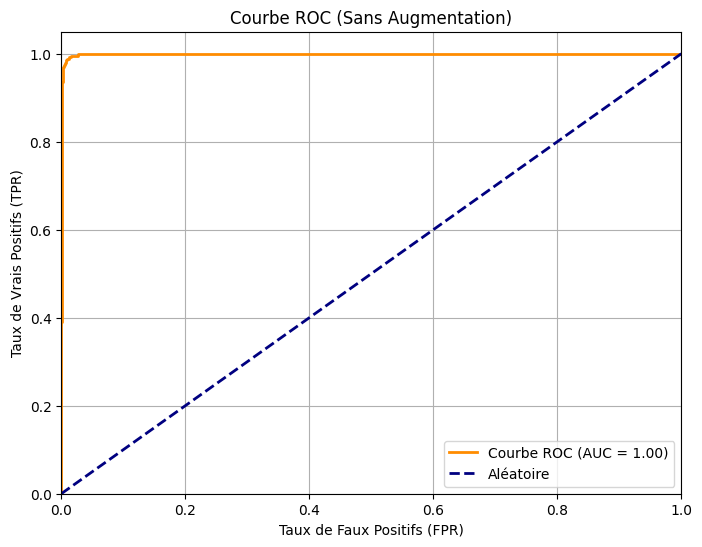

AUC (Area Under the Curve) : 1.00


In [59]:
from sklearn.metrics import roc_curve, auc

# Calculer la courbe ROC
fpr_no_aug, tpr_no_aug, thresholds_no_aug = roc_curve(true_labels_no_aug, predictions_no_aug)

# Calculer l'AUC (Area Under the Curve)
roc_auc_no_aug = auc(fpr_no_aug, tpr_no_aug)

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_no_aug, tpr_no_aug, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc_no_aug:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC (Sans Augmentation)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC (Area Under the Curve) : {roc_auc_no_aug:.2f}")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_datagen_aug = ImageDataGenerator(
    rescale=1./255,                 
    rotation_range=10,
    width_shift_range=0.1,          
    height_shift_range=0.1,        
    shear_range=0.1,                
    zoom_range=0.1,                 
    horizontal_flip=True,           
    fill_mode='nearest'             
)

val_train_datagen_aug = ImageDataGenerator(
    rescale=1./255
)

k_color_mode = 'grayscale' if COLOR_MODE == 'L' else COLOR_MODE.lower()

train_generator_resampled_aug = train_datagen_aug.flow_from_dataframe(
    dataframe=train_df_resampled,
    x_col='filepath',
    y_col='target',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=k_color_mode,
    class_mode='binary',
    shuffle=True,
    seed=42
)

validation_generator_aug = val_train_datagen_aug.flow_from_dataframe(
    dataframe=val_gen_df,
    x_col='filepath',
    y_col='target',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=k_color_mode,
    class_mode='binary',
    shuffle=False,
    seed=42
)


train_generator_aug = val_train_datagen_aug.flow_from_dataframe(
    dataframe=train_gen_df,
    x_col='filepath',
    y_col='target',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=k_color_mode,
    class_mode='binary',
    shuffle=False,
    seed=42
)

print("\nIndices de classe pour le générateur d'entraînement suréchantillonné et augmenté:")
print(train_generator_resampled_aug.class_indices)

Found 16306 validated image filenames belonging to 2 classes.
Found 2186 validated image filenames belonging to 2 classes.
Found 2813 validated image filenames belonging to 2 classes.

Indices de classe pour le générateur d'entraînement suréchantillonné et augmenté:
{'0': 0, '1': 1}


In [ ]:
from tensorflow.keras import layers, models, Input
from tensorflow.keras.layers import Dropout


model_aug = models.Sequential([
    Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 1)), 
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    Dropout(0.5),
    layers.Dense(1, activation='sigmoid') # Couche de sortie pour classification binaire
])

# Compiler le modèle
model_aug.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Afficher le résumé du modèle
model_aug.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Callback d'arrêt anticipé
early_stopping_aug = EarlyStopping(
    monitor="val_loss",
    patience=3, 
    restore_best_weights=True
)

epochs_aug = 5 

history_aug = model_aug.fit(
    train_generator_resampled_aug,
    steps_per_epoch=len(train_generator_resampled_aug),
    epochs=epochs_aug,
    validation_data=validation_generator_aug,
    validation_steps=len(validation_generator_aug),
    callbacks=[early_stopping_aug],
    verbose=1
)

Epoch 1/5
510/510 ━━━━━━━━━━━━━━━━━━━━ 1906s 4s/step - accuracy: 0.6673 - loss: 0.6049 - val_accuracy: 0.8239 - val_loss: 0.3748
Epoch 2/5
510/510 ━━━━━━━━━━━━━━━━━━━━ 1900s 4s/step - accuracy: 0.7900 - loss: 0.4471 - val_accuracy: 0.8989 - val_loss: 0.2399
Epoch 3/5
510/510 ━━━━━━━━━━━━━━━━━━━━ 1941s 4s/step - accuracy: 0.8448 - loss: 0.3549 - val_accuracy: 0.8838 - val_loss: 0.2544
Epoch 4/5
510/510 ━━━━━━━━━━━━━━━━━━━━ 1943s 4s/step - accuracy: 0.8712 - loss: 0.3028 - val_accuracy: 0.9428 - val_loss: 0.1511
Epoch 5/5
510/510 ━━━━━━━━━━━━━━━━━━━━ 1898s 4s/step - accuracy: 0.8879 - loss: 0.2711 - val_accuracy: 0.9565 - val_loss: 0.1349


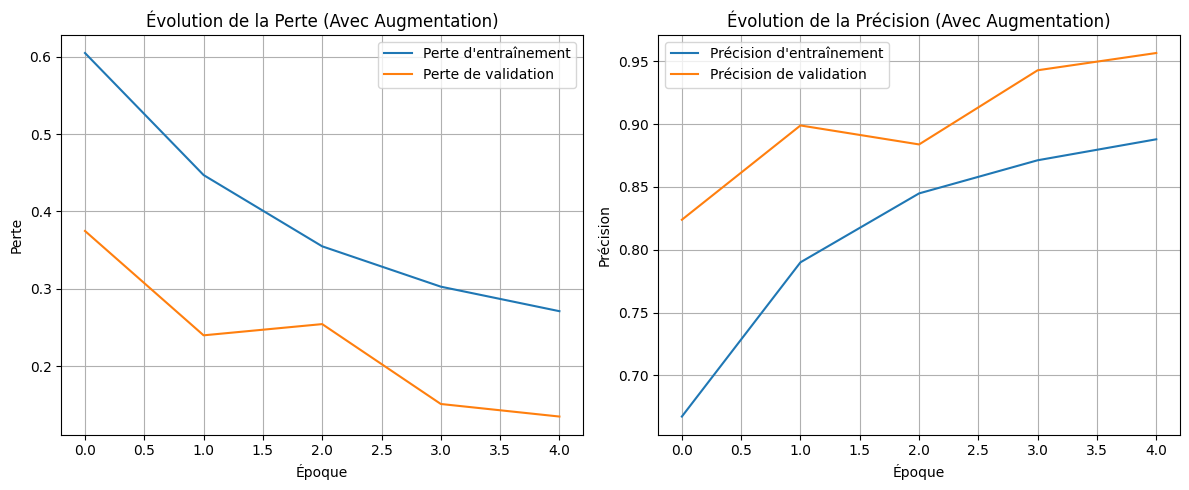

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_aug.history['loss'], label='Perte d\'entraînement')
plt.plot(history_aug.history['val_loss'], label='Perte de validation')
plt.title('Évolution de la Perte (Avec Augmentation)')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_aug.history['accuracy'], label='Précision d\'entraînement')
plt.plot(history_aug.history['val_accuracy'], label='Précision de validation')
plt.title('Évolution de la Précision (Avec Augmentation)')
plt.xlabel('Époque')
plt.ylabel('Précision')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

88/88 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step


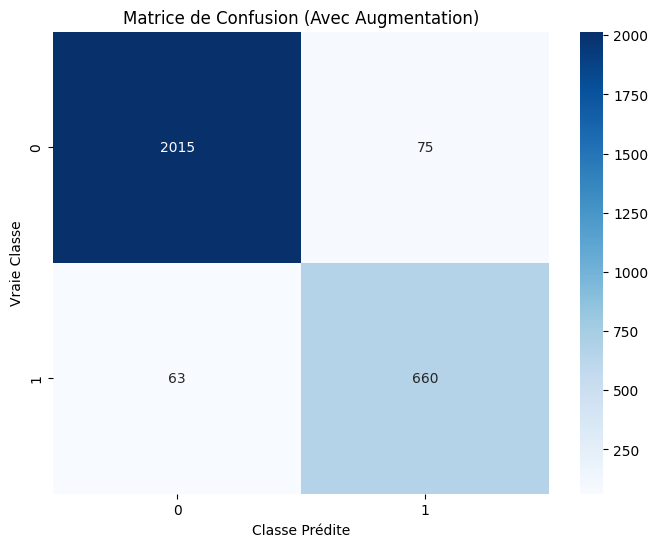


Rapport de classification (Avec Augmentation) :

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      2090
           1       0.90      0.91      0.91       723

    accuracy                           0.95      2813
   macro avg       0.93      0.94      0.94      2813
weighted avg       0.95      0.95      0.95      2813



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


predictions_aug = model_aug.predict(train_generator_aug)


predictions_classes_aug = (predictions_aug > 0.5).astype(int)

true_labels_aug = train_generator_aug.classes

# Calculer la matrice de confusion
cm_aug = confusion_matrix(true_labels_aug, predictions_classes_aug)


class_names_aug = list(train_generator_aug.class_indices.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_aug,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names_aug,
    yticklabels=class_names_aug
)
plt.title('Matrice de Confusion (Avec Augmentation)')
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.show()

print("\nRapport de classification (Avec Augmentation) :\n")
print(classification_report(true_labels_aug, predictions_classes_aug, target_names=class_names_aug))

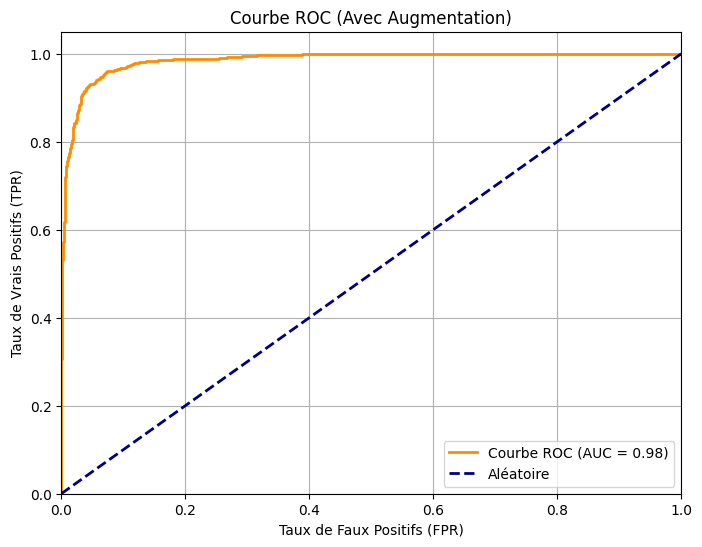

AUC (Area Under the Curve) : 0.98


In [ ]:
from sklearn.metrics import roc_curve, auc

# Calculer la courbe ROC
fpr_aug, tpr_aug, thresholds_aug = roc_curve(true_labels_aug, predictions_aug)


roc_auc_aug = auc(fpr_aug, tpr_aug)

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_aug, tpr_aug, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc_aug:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC (Avec Augmentation)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC (Area Under the Curve) : {roc_auc_aug:.2f}")